In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import engine

plt.style.use('default')  # prevent dark theme from affecting plot background


In [2]:
root_path = r'/root/shared-nvme/lingqiData/Model/V5.3'
fac_path = r'/root/shared-nvme/lingqiData/trainingdata/V3/'
fac_name = r'fac20260523'
label_path = r'/root/shared-nvme/lingqiData/trainingdata/V3/'
label_name = r'label'
liquid_path = r'/root/shared-nvme/lingqiData/trainingdata/V3/'
liquid_name = r'trade_amt'
start = '20230101'
end = '20260331'
calendar_path = r'/root/shared-nvme/lingqiData/data/calendar.parquet'
bench1_path = r"/root/shared-nvme/lingqiData/Model/bench/20260515.fea"
bench2_path = r"/root/shared-nvme/lingqiData/Model/bench/20260524.fea"
watchlist_path = r'/root/shared-nvme/lingqiData/MyCode.txt'


model_test_path = rf'{root_path}/model_test/nn--{fac_name}--label--dropout0.2'
model_res_path = rf'{root_path}/model_res'
fac_path = rf'{label_path}/{fac_name}.fea'
model_train_base = rf'{root_path}/model_train'

MONEY = 1.5e9             # 资金规模
TOP_N = 1                 # 买入股票数量
EXCLUDE_LIMIT_UP = False  # 是否排除涨停板（涨幅>=9.5%）
LABEL_HORIZON_DAYS = 5    # 模型目标对应的持仓天数（label_ret_1d → 1天）
SEASON = '2026q2'         # 预测季度

class params:
    liquid_data = pd.read_feather(rf"{liquid_path}/{liquid_name}.fea").set_index("index")
    ret_data = pd.read_feather(rf"{label_path}/{label_name}.fea").set_index("index")


In [3]:

def print_quarterly_metrics(ret, ic):
    """打印每个季度的收益和IC指标"""
    ret_series = ret.copy()
    ic_series = ic.copy()
    ret_series.index = pd.to_datetime(ret_series.index)
    ic_series.index = pd.to_datetime(ic_series.index)
    quarterly_ret = ret_series.groupby(pd.Grouper(freq='QE')).mean()
    quarterly_ic = ic_series.groupby(pd.Grouper(freq='QE')).mean()
    quarterly_ret.index = [f"{idx.year}Q{idx.quarter}" for idx in quarterly_ret.index]
    quarterly_ic.index = [f"{idx.year}Q{idx.quarter}" for idx in quarterly_ic.index]
    quarterly_df = pd.DataFrame({
        '季度平均收益': quarterly_ret.round(4),
        '季度平均IC': quarterly_ic.round(4)
    })
    print("\n===== 季度表现指标 =====")
    print(quarterly_df)
    print("=======================\n")


def print_metrics(model_metrics, bench_metrics=None, title="模型评估结果"):
    metric_keys = list(model_metrics.keys())
    df = pd.DataFrame(index=metric_keys)
    df.index.name = "指标"
    df["模型值"] = [model_metrics[k] for k in metric_keys]
    if bench_metrics is not None:
        df["基准值"] = [bench_metrics.get(k, None) for k in metric_keys]
        df["提升值"] = ((df["模型值"] - df["基准值"]) / df["基准值"]) * 100
    print(f"\n{title}")
    print(df.round(4))


def plot_model(model_score, bench_score, ret_data, liquid_data,
               start='20230101', end='20241231', money=1.5e9):
    model_ret, _ = engine.get_ret_ic(model_score, ret_data, liquid_data,
                                     start=start, end=end, money=money)
    model_ret = model_ret / 100
    bench_ret, _ = engine.get_ret_ic(bench_score, ret_data, liquid_data,
                                     start=start, end=end, money=money)
    bench_ret = bench_ret / 100

    dates = model_ret.index.tolist()
    seen_months = set()
    month_ticks = []
    month_labels = []
    for i, d in enumerate(dates):
        month = d[:6]
        if month not in seen_months:
            seen_months.add(month)
            month_ticks.append(i)
            month_labels.append(d)

    # 1. 每日收益率曲线
    plt.figure(figsize=(12, 6))
    plt.plot(dates, model_ret.cumsum(), label='model', color='blue')
    plt.plot(dates, bench_ret.cumsum(), label='bench', color='orange')
    plt.title('Cumulative Return Of Model & Bench', fontsize=14)
    plt.ylabel('Cumulative Return', fontsize=12)
    plt.xticks(ticks=month_ticks, labels=month_labels, rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # 2. 相对提升
    plt.figure(figsize=(12, 6))
    relative_improvement = model_ret - bench_ret
    plt.plot(dates, relative_improvement.cumsum(), label='model', color='blue')
    plt.title('Relative Improvement', fontsize=14)
    plt.ylabel('Relative Improvement', fontsize=12)
    plt.xticks(ticks=month_ticks, labels=month_labels, rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()


# bench

In [4]:
# 收集模型训练结果
model_score = engine.concat_model_4fold(test_path=model_test_path, res_path=model_res_path)
os.makedirs(model_res_path, exist_ok=True)
model_score.reset_index().to_feather(rf"{model_res_path}/zscore_score.fea")

# 暂时没有bench，四个bench都用自己代替
bench1 = pd.read_feather(bench1_path).set_index("date")
bench2 = pd.read_feather(bench2_path).set_index("date")
bench3 = model_score.copy()
bench4 = model_score.copy()

bench_all = engine.ensemble_scores(bench1, bench2, bench3, bench4)
de_series = bench_all.groupby('date').apply(engine.diversity_entropy)
print(f'现有子模型的多样性熵：{de_series.mean()}')
print('各子模型之间的相关性：')
print(bench_all.groupby('date').corr().unstack().mean().unstack())

bench_all = bench_all.mean(axis=1).unstack()
bench_ret, bench_ic = engine.get_ret_ic(bench_all, params.ret_data, params.liquid_data,
                                        start=start, end=end, money=MONEY)
print_quarterly_metrics(bench_ret, bench_ic)
bench_all_metrics = engine.get_metrics(bench_ret, bench_ic)
print_metrics(bench_all_metrics)

现有子模型的多样性熵：0.4078509745814512
各子模型之间的相关性：
          score1    score2    score3    score4
score1  1.000000  0.624673  0.646244  0.646244
score2  0.624673  1.000000  0.821399  0.821399
score3  0.646244  0.821399  1.000000  1.000000
score4  0.646244  0.821399  1.000000  1.000000

===== 季度表现指标 =====
        季度平均收益  季度平均IC
2024Q1  3.2057  0.0867
2024Q2 -0.0625  0.0620
2024Q3  1.9986  0.1076
2024Q4  5.0463  0.1008
2025Q1  1.3596  0.1097
2025Q2  2.7419  0.1076
2025Q3  2.2608  0.0540
2025Q4  1.6435  0.0631
2026Q1  0.2115  0.0577


模型评估结果
                         模型值
指标                          
IC                    0.0832
ICIR                  0.6946
top_return            2.0696
top_return_stability  0.3144


# 使用示例

---单一模型评估---

===== 季度表现指标 =====
        季度平均收益  季度平均IC
2024Q1  3.7945  0.0840
2024Q2  0.2495  0.0656
2024Q3  1.9249  0.1072
2024Q4  5.1604  0.0975
2025Q1  0.0183  0.1033
2025Q2  2.1373  0.0905
2025Q3  2.9149  0.0536
2025Q4  1.3682  0.0573
2026Q1  1.3957  0.0552


模型评估结果
                         模型值
指标                          
IC                    0.0794
ICIR                  0.7438
top_return            2.1344
top_return_stability  0.3234
---该模型与现有集成模型的相关性---
0.9584
---模型集成评估---
加入当前模型后的多样性熵：0.31662535124703595
当前模型与现有子模型之间的相关性：
          score1    score2    score3    score4    score5
score1  1.000000  0.624673  0.646244  0.646244  0.646244
score2  0.624673  1.000000  0.821399  0.821399  0.821399
score3  0.646244  0.821399  1.000000  1.000000  1.000000
score4  0.646244  0.821399  1.000000  1.000000  1.000000
score5  0.646244  0.821399  1.000000  1.000000  1.000000

===== 季度表现指标 =====
        季度平均收益  季度平均IC
2024Q1  3.3854  0.0868
2024Q2  0.1320  0.0633
2024Q3  1.9846  0.1083
2024Q4  

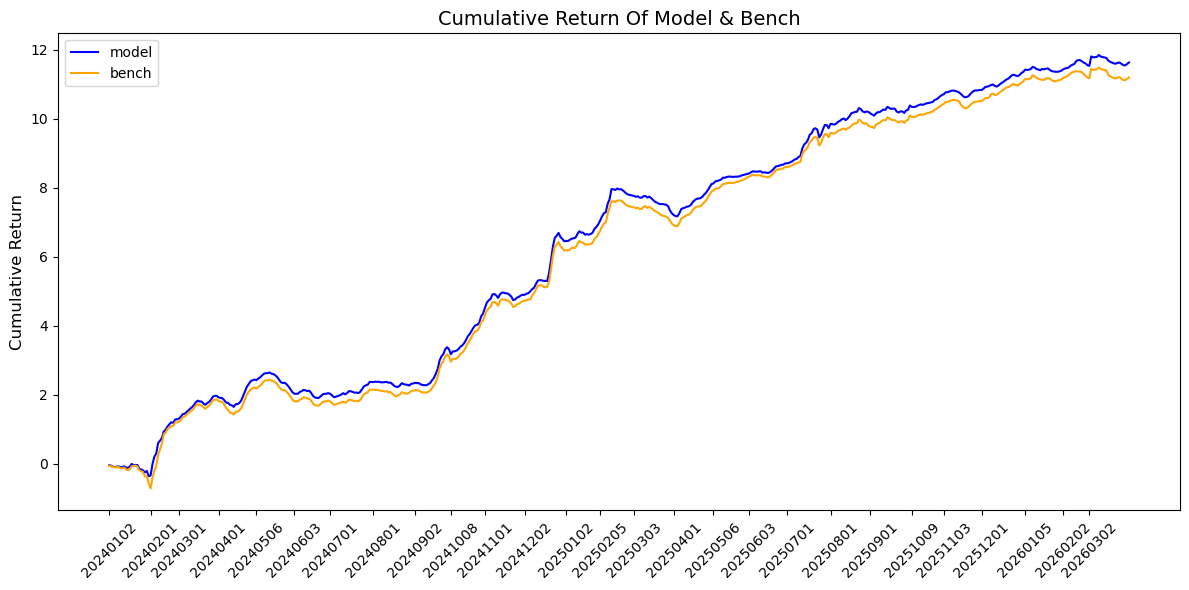

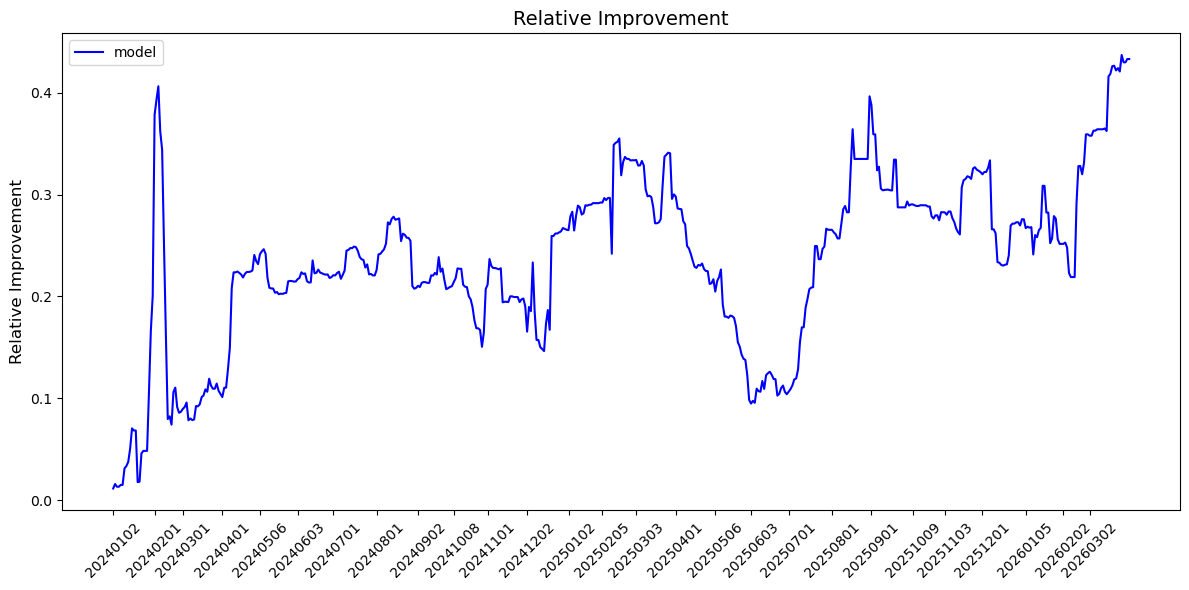

In [5]:
# 单模型效果评估（完整季度输出）
# 注意：当前 bench = 模型自身，集成评估无实际意义，待有真实 bench 后替换 bench1~4 即可
print("---单一模型评估---")
ret1, ic1 = engine.get_ret_ic(model_score, params.ret_data, params.liquid_data,
                              start=start, end=end, money=MONEY)
print_quarterly_metrics(ret1, ic1)
score1_metrics = engine.get_metrics(ret1, ic1)
print_metrics(score1_metrics)

# TODO: 有真实bench后，取消下面注释并替换 bench1~4
print("---该模型与现有集成模型的相关性---")
corr_with_bench = model_score.reindex(
    columns=bench_all.columns, index=bench_all.index
).corrwith(bench_all, axis=1)
print(f"{corr_with_bench.mean():.4f}")

print("---模型集成评估---")
bench_new = engine.ensemble_scores(bench1, bench2, bench3, bench4, model_score)
print(f'加入当前模型后的多样性熵：{bench_new.groupby("date").apply(engine.diversity_entropy).mean()}')
print('当前模型与现有子模型之间的相关性：')
print(bench_new.groupby('date').corr().unstack().mean().unstack())

bench_new_score = bench_new.mean(axis=1).unstack()
ret_new, ic_new = engine.get_ret_ic(bench_new_score, params.ret_data, params.liquid_data,
                                    start=start, end=end, money=MONEY)
print_quarterly_metrics(ret_new, ic_new)
bench_new_metrics = engine.get_metrics(ret_new, ic_new)
print_metrics(bench_new_metrics, bench_all_metrics)
plot_model(bench_new_score, bench_all, params.ret_data, params.liquid_data,
           start=start, end=end, money=MONEY)

# 通用个人策略 vs Top 500 机构策略
# 自定义买入数量 + 涨停板过滤（涨幅>=9.5%不能买入）
# 使用 run_individual_strategy() 函数，修改 TOP_N 和 EXCLUDE_LIMIT_UP 即可


===== 多策略对比 =====
策略                                      年化收益     夏普比率       季均收益
-----------------------------------------------------------------
Top 500 (机构, 流动性约束)                   537.86%   5.1340     2.1071%
Top 1 (个人, 不过滤涨停)                    1008.76%   3.2824     4.0020%
Top 3 (个人, 不过滤涨停)                    1030.55%   4.7107     4.0441%
Top 5 (个人, 不过滤涨停)                     994.07%   5.2136     3.9004%
Top 10 (个人, 不过滤涨停)                    689.41%   5.9974     2.6969%
Top 20 (个人, 不过滤涨停)                    522.06%   6.2760     2.0425%


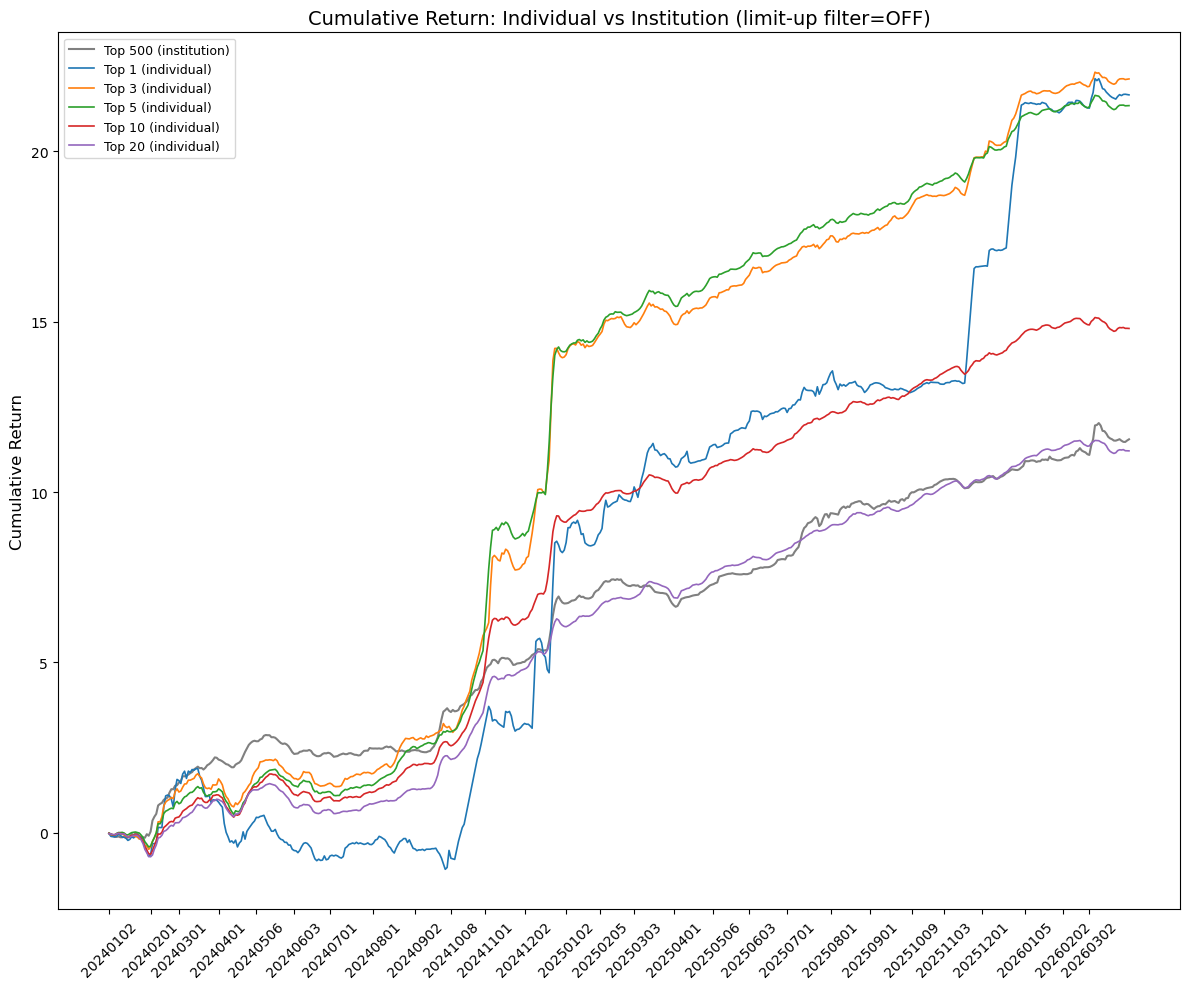

In [6]:
# ============================================================
# 通用个人策略：自定义买入数量 + 涨停板过滤
# 用法：修改顶部配置区的 TOP_N 和 EXCLUDE_LIMIT_UP，然后运行本单元格
# ============================================================

# Top 500 机构策略（用于对比）
top500_ret, _ = engine.get_ret_ic(model_score, params.ret_data, params.liquid_data,
                                  start=start, end=end, money=MONEY)
top500_ret = top500_ret / 100


# ---- 辅助函数 ----
def _print_strategy(label, ret_series):
    ann = ret_series.mean() * 252 * 100
    sharpe = (ret_series.mean() / ret_series.std() * np.sqrt(252)
              if ret_series.std() > 0 else 0)
    q_avg = ret_series.groupby(
        pd.to_datetime(ret_series.index).to_period('Q')
    ).mean().mean() * 100
    print(f"{label:<35} {ann:>8.2f}% {sharpe:>8.4f} {q_avg:>10.4f}%")


# ---- 多策略对比 ----
print("\n===== 多策略对比 =====")
print(f"{'策略':<35} {'年化收益':>8} {'夏普比率':>8} {'季均收益':>10}")
print("-" * 65)
_print_strategy("Top 500 (机构, 流动性约束)", top500_ret)

for n in [1, 3, 5, 10, 20]:
    r, s = engine.run_individual_strategy(model_score, params.ret_data, top_n=n,
                                          exclude_limit_up=EXCLUDE_LIMIT_UP,
                                          start=start, end=end)
    _print_strategy(f"Top {n} (个人, 不过滤涨停)", r)


# ---- 绘图对比 ----
dates = top500_ret.index.tolist()
seen_months = set()
month_ticks, month_labels = [], []
for i, d in enumerate(dates):
    month = d[:6]
    if month not in seen_months:
        seen_months.add(month)
        month_ticks.append(i)
        month_labels.append(d)

fig, axes = plt.subplots(1, 1, figsize=(12, 10))

axes.plot(dates, top500_ret.cumsum(), label='Top 500 (institution)',
          color='gray', linewidth=1.5)
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
for i, n in enumerate([1, 3, 5, 10, 20]):
    r, _ = engine.run_individual_strategy(model_score, params.ret_data, top_n=n,
                                          exclude_limit_up=EXCLUDE_LIMIT_UP,
                                          start=start, end=end)
    axes.plot(dates, r.cumsum(), label=f'Top {n} (individual)',
              color=colors[i], linewidth=1.2)
axes.set_title(
    f'Cumulative Return: Individual vs Institution '
    f'(limit-up filter={"ON" if EXCLUDE_LIMIT_UP else "OFF"})',
    fontsize=14
)
axes.set_ylabel('Cumulative Return', fontsize=12)
axes.set_xticks(month_ticks)
axes.set_xticklabels(month_labels, rotation=45)
axes.legend(fontsize=9)

plt.tight_layout()
plt.show()

# 预测补充 & 最新推荐
自动检测 factor 数据中超出 model_res 覆盖范围的日期，使用最优模型进行预测，并展示最新打分结果与投资建议。

In [7]:
# ============================================================
# 1. 自动预测：补充 model_res 未覆盖的最新日期
# ============================================================

new_scores = engine.predict_missing_dates(model_score, fac_path=fac_path,
                                           model_train_base=model_train_base,
                                           calendar_path=calendar_path,
                                           season=SEASON)

if new_scores is not None:
    model_score_extended = pd.concat([model_score, new_scores], axis=0).sort_index()
    print(f"合并完成：原始 {len(model_score)} 天 + 新增 {len(new_scores)} 天 = {len(model_score_extended)} 天")
    print(f"新增日期: {list(new_scores.index)}")

    # 落盘到 model_pred
    basic_name = 'nn--fac20260523--label--dropout0.2'
    pred_dir = rf'{root_path}/model_pred/{basic_name}/{SEASON}'
    engine.save_predictions(new_scores, pred_dir)
else:
    model_score_extended = model_score.copy()
    print("无新增日期，使用原始 model_score。")

[predict] Found 9 uncovered trading days: ['20260515', '20260518', '20260519', '20260520', '20260521', '20260522', '20260525', '20260526', '20260527']
[predict] Using 200/200 training-time factors
[predict] Using 4 folds for prediction
[predict]   [fold1] epoch=11-val_wei=3.9636.ckpt (val_wei=3.9636)
[predict]   [fold2] epoch=11-val_wei=3.6848.ckpt (val_wei=3.6848)
[predict]   [fold3] epoch=52-val_wei=2.9822.ckpt (val_wei=2.9822)
[predict]   [fold4] epoch=34-val_wei=6.6365.ckpt (val_wei=6.6365)
[predict]   [20260515] done, 2542 stocks
[predict]   [20260518] done, 2542 stocks
[predict]   [20260519] done, 2542 stocks
[predict]   [20260520] done, 2542 stocks
[predict]   [20260521] done, 2542 stocks
[predict]   [20260522] done, 2542 stocks
[predict]   [20260525] done, 2542 stocks
[predict]   [20260526] done, 2542 stocks
[predict]   [20260527] done, 2542 stocks
[predict] Done, 9 days total.
合并完成：原始 569 天 + 新增 9 天 = 578 天
新增日期: ['20260515', '20260518', '20260519', '20260520', '20260521', '20

In [8]:
# ============================================================
# 1.5 历史验证：预测 model_test 最后 3 天，与已有结果对比一致性
# ============================================================

hist_dates = sorted(model_score.index)[-3:]
print(f"历史验证日期: {hist_dates}")

hist_scores = engine.predict_dates(hist_dates, fac_path=fac_path,
                                    model_train_base=model_train_base,
                                    season=SEASON)

if hist_scores is not None:
    # 落盘
    basic_name = 'nn--fac20260523--label--dropout0.2'
    hist_dir = rf'{root_path}/model_pred/{basic_name}/{SEASON}'
    engine.save_predictions(hist_scores, hist_dir)

    print("\n--- 与 model_test 一致性验证 ---")
    for date in hist_dates:
        if date in hist_scores.index and date in model_score.index:
            old = model_score.loc[date]
            new = hist_scores.loc[date]
            common = old.index.intersection(new.index)
            if len(common) > 0:
                corr = old[common].corr(new[common])
                print(f"  {date}: corr={corr:.6f}, 共同股票数={len(common)}")
            else:
                print(f"  {date}: 无共同股票")

历史验证日期: ['20260512', '20260513', '20260514']
[predict] Using 200/200 training-time factors
[predict] Using 4 folds for prediction
[predict]   [fold1] epoch=11-val_wei=3.9636.ckpt (val_wei=3.9636)
[predict]   [fold2] epoch=11-val_wei=3.6848.ckpt (val_wei=3.6848)
[predict]   [fold3] epoch=52-val_wei=2.9822.ckpt (val_wei=2.9822)
[predict]   [fold4] epoch=34-val_wei=6.6365.ckpt (val_wei=6.6365)
[predict]   [20260512] done, 2542 stocks
[predict]   [20260513] done, 2542 stocks
[predict]   [20260514] done, 2542 stocks
[predict] Done, 3 days total.
[save] 20260512 -> /root/shared-nvme/lingqiData/Model/V5.3/model_pred/nn--fac20260523--label--dropout0.2/2026q2/20260512.pkl
[save] 20260513 -> /root/shared-nvme/lingqiData/Model/V5.3/model_pred/nn--fac20260523--label--dropout0.2/2026q2/20260513.pkl
[save] 20260514 -> /root/shared-nvme/lingqiData/Model/V5.3/model_pred/nn--fac20260523--label--dropout0.2/2026q2/20260514.pkl

--- 与 model_test 一致性验证 ---
  20260512: corr=0.999978, 共同股票数=2542
  20260513: 

In [9]:
# ============================================================
# 2. 最新推荐展示：股票名称映射、Top 打分、投资建议
# ============================================================

# --- 股票代码 → 名称映射 ---
stock_info = pd.read_parquet('/root/shared-nvme/lingqiData/data/list.parquet')
stock_info = stock_info[stock_info['list_status'] == 'L']
code_to_name = {
    re.sub(r'\.(SZ|SH|BJ)$', '', row['stock_code']): row['name']
    for _, row in stock_info.iterrows()
}

# --- 交易日历 ---
cal = pd.read_parquet('/root/shared-nvme/lingqiData/data/calendar.parquet')
cal = cal[cal['is_open'] == 1]
_trade_dates = sorted(cal['date'].astype(str).str.replace('-', '').tolist())


def get_nth_next_trade_date(date_str, n=1):
    """获取 date_str 之后第 n 个交易日"""
    try:
        idx = _trade_dates.index(date_str)
        if idx + n < len(_trade_dates):
            return _trade_dates[idx + n]
    except (ValueError, IndexError):
        pass
    return None


def fmt_date(date_str):
    if date_str is None:
        return "待定（交易日历未覆盖）"
    return f"{date_str[:4]}年{int(date_str[4:6])}月{int(date_str[6:8])}日"


# ============================================================
# 数据当前日期 & 预测日期推算
# ============================================================

# 原始 model_res 的最新日期（有真实 label 的最后一天）
last_label_date = model_score.index.max()

# 因子数据的最新日期（即这一批数据的"当前日期"）
latest_factor_date = model_score_extended.index.max()

# 本次新增的预测日期（model_res 未覆盖、通过 prediction 补充的日期）
predicted_dates = sorted(set(model_score_extended.index) - set(model_score.index))
predicted_dates.sort()


# ============================================================
# 展示预测日期的 Top 推荐
# ============================================================
print()
print("=" * 72)
print("                    最新模型打分 Top 推荐")
print("=" * 72)

for date in predicted_dates:
    scores = model_score_extended.loc[date].sort_values(ascending=False)
    buy_date = get_nth_next_trade_date(date, 1)
    sell_date = get_nth_next_trade_date(buy_date, LABEL_HORIZON_DAYS) if buy_date else None

    print(f"\n{'─' * 60}")
    print(f"  当前日期：{fmt_date(latest_factor_date)} 收盘")
    if buy_date and sell_date:
        print(f"  模型预测{LABEL_HORIZON_DAYS}日收益率：{fmt_date(buy_date)} 买入 → {fmt_date(sell_date)} 卖出")
    elif buy_date:
        print(f"  模型预测{LABEL_HORIZON_DAYS}日收益率：{fmt_date(buy_date)} 买入 → {fmt_date(sell_date)}")
    else:
        print(f"  模型预测{LABEL_HORIZON_DAYS}日收益率：无法推算交易日（需更新交易日历）")
    print(f"{'─' * 60}")

    top_n = min(10, len(scores))
    print(f"\n  {'排名':<5}{'代码':<10}{'名称':<12}{'打分':>10}")
    print(f"  {'-' * 37}")
    for rank, (code, score) in enumerate(scores.head(top_n).items(), 1):
        name = code_to_name.get(code, '未知')
        sign = '+' if score > 0 else ''
        print(f"  {rank:<5}{code:<10}{name:<12}{sign}{score:>9.4f}")


                    最新模型打分 Top 推荐

────────────────────────────────────────────────────────────
  当前日期：2026年5月27日 收盘
  模型预测5日收益率：2026年5月18日 买入 → 2026年5月25日 卖出
────────────────────────────────────────────────────────────

  排名   代码        名称                  打分
  -------------------------------------
  1    600183    生益科技        +  12.7017
  2    600584    长电科技        +   8.3644
  3    000938    紫光股份        +   8.2941
  4    601138    工业富联        +   7.6684
  5    603669    灵康药业        +   7.6214
  6    603232    格尔软件        +   7.5503
  7    603799    华友钴业        +   7.4264
  8    002829    星网宇达        +   7.1923
  9    000702    正虹科技        +   7.1274
  10   600843    上工申贝        +   7.0576

────────────────────────────────────────────────────────────
  当前日期：2026年5月27日 收盘
  模型预测5日收益率：2026年5月19日 买入 → 2026年5月26日 卖出
────────────────────────────────────────────────────────────

  排名   代码        名称                  打分
  -------------------------------------
  1    002272    川润股份        + 

# 自选股排序
从 `/root/shared-nvme/lingqiData/MyCode.txt` 读取自选股列表，展示全部自选股在最新预测日期上的打分排名。

In [10]:
# ============================================================
# 自选股排序：读取 MyCode.txt，展示全部自选股打分
# ============================================================

watchlist = np.loadtxt(watchlist_path)
watchlist_codes = [str(int(code)).zfill(6) for code in watchlist]

for date in predicted_dates:
    scores = model_score_extended.loc[date]
    buy_date = get_nth_next_trade_date(date, 1)
    sell_date = get_nth_next_trade_date(buy_date, LABEL_HORIZON_DAYS) if buy_date else None

    watch_scores = scores.reindex(watchlist_codes).dropna().sort_values(ascending=False)
    missing = [c for c in watchlist_codes if c not in scores.index]

    # 全市场排名（1 = 最优）
    all_ranks = scores.rank(ascending=False).astype(int)
    total = len(scores)

    print(f"\n{'─' * 60}")
    print(f"  自选股打分排序")
    print(f"  当前日期：{fmt_date(latest_factor_date)} 收盘")
    if buy_date and sell_date:
        print(f"  模型预测{LABEL_HORIZON_DAYS}日收益率：{fmt_date(buy_date)} 买入 → {fmt_date(sell_date)} 卖出")
    elif buy_date:
        print(f"  模型预测{LABEL_HORIZON_DAYS}日收益率：{fmt_date(buy_date)} 买入 → {fmt_date(sell_date)}")
    else:
        print(f"  模型预测{LABEL_HORIZON_DAYS}日收益率：无法推算交易日（需更新交易日历）")
    print(f"{'─' * 60}")

    print(f"\n  {'排名':<5}{'代码':<10}{'名称':<12}{'打分':>10}  {'总排名':>8}  {'百分位':>10}")
    print(f"  {'─' * 55}")
    for rank, (code, score) in enumerate(watch_scores.items(), 1):
        name = code_to_name.get(code, '未知')
        sign = '+' if score > 0 else ''
        total_rank = all_ranks.get(code, '-')
        pct = f'{total_rank / total * 100:.2f}%' if total_rank != '-' else '-'
        print(f"  {rank:<5}{code:<10}{name:<12}{sign}{score:>9.4f}  {str(total_rank):>8}/{total}  {pct:>10}")

    if missing:
        print(f"\n  以下自选股无模型打分（可能已退市或不在股票池中）：{missing}")




────────────────────────────────────────────────────────────
  自选股打分排序
  当前日期：2026年5月27日 收盘
  模型预测5日收益率：2026年5月18日 买入 → 2026年5月25日 卖出
────────────────────────────────────────────────────────────

  排名   代码        名称                  打分       总排名         百分位
  ───────────────────────────────────────────────────────
  1    601138    工业富联        +   7.6684         4/2542       0.16%
  2    002466    天齐锂业        +   5.3554        54/2542       2.12%
  3    600030    中信证券        +   4.6324       105/2542       4.13%
  4    000725    京东方Ａ        +   0.3325      1254/2542      49.33%
  5    002230    科大讯飞          -0.2358      1460/2542      57.44%
  6    000100    TCL科技         -0.4496      1561/2542      61.41%
  7    601933    永辉超市          -0.6172      1641/2542      64.56%
  8    601888    中国中免          -0.7465      1696/2542      66.72%
  9    000651    格力电器          -1.3074      1922/2542      75.61%
  10   601360    三六零           -1.8773      2085/2542      82.02%
  11   601919    中远

# 个股连续变化查询
输入股票代码和回顾天数 K，展示该股票在最新连续 K 个交易日内的打分与排名变化，并画图。


  Stock Trend: 603078 / 江化微
  Lookback      : 10 days (20260515 ~ 20260528)
  Valid days    : 10
  Score change  : +6.2695 -> +11.1631  (+4.8936)
  Rank  change  : 32 -> 1  (UP 31)
  Score range   : -9.8456 ~ +11.1631
  Rank  range   : 1 ~ 2491

  BuyDate          Score    Rank       Pct
  ----------------------------------------
  20260515    +   6.2695      32     1.26%
  20260518    +   3.5645     242     9.52%
  20260519      -5.4806    2418    95.12%
  20260520      -9.8456    2491    97.99%
  20260521      -3.3865    2301    90.52%
  20260522    +   5.2197      47     1.85%
  20260525    +   6.4221      14     0.55%
  20260526    +   5.4262      34     1.34%
  20260527    +   9.4677       3     0.12%
  20260528    +  11.1631       1     0.04%


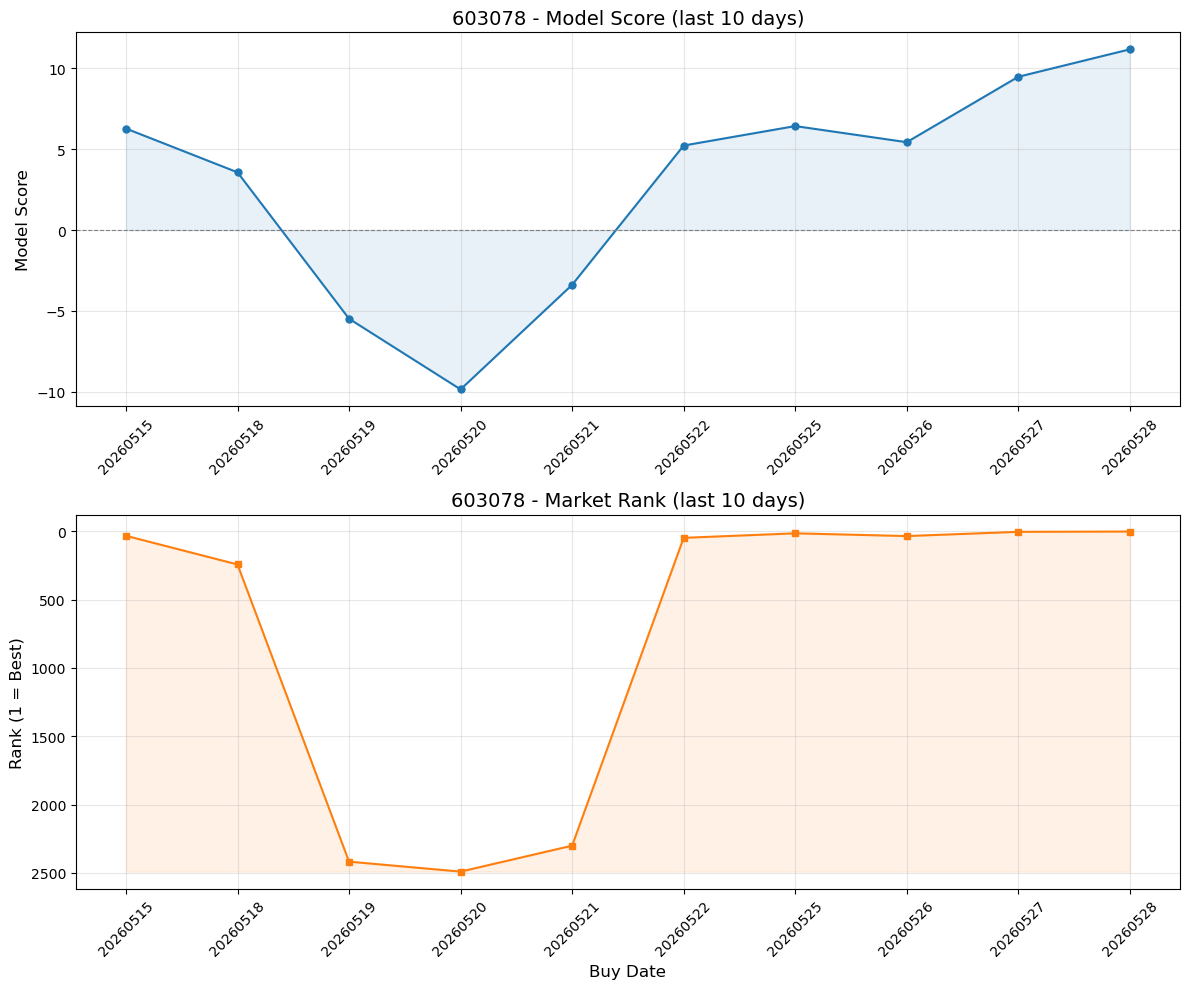

In [12]:
# ============================================================
# Stock Score Trend: query a stock's score & rank over the last K trading days
# Factor date +1 trading day = actual buy date, X-axis uses buy dates
# Usage: modify query_code and K, then run this cell
# ============================================================

query_code = '603078'   # <-- stock code (6 digits)
K = 10                  # <-- lookback window (trading days)

code_name = code_to_name.get(query_code, 'N/A')
scores_all = model_score_extended

# --- Last K trading days ---
all_dates = sorted(scores_all.index)
recent_dates = all_dates[-K:] if len(all_dates) >= K else all_dates

# --- Extract score & rank for each day ---
scores_list = []
ranks_list = []
pcts_list = []
for d in recent_dates:
    day_scores = scores_all.loc[d].dropna().sort_values(ascending=False)
    total = len(day_scores)
    if query_code in day_scores.index:
        s = day_scores[query_code]
        r = day_scores.index.get_loc(query_code) + 1
        scores_list.append(s)
        ranks_list.append(r)
        pcts_list.append(r / total * 100)
    else:
        scores_list.append(None)
        ranks_list.append(None)
        pcts_list.append(None)

valid_factor_dates = [d for i, d in enumerate(recent_dates) if scores_list[i] is not None]
valid_scores = [s for s in scores_list if s is not None]
valid_ranks = [r for r in ranks_list if r is not None]
valid_pcts = [p for p in pcts_list if p is not None]

# --- Date +1: factor date -> buy date ---
valid_buy_dates = [get_nth_next_trade_date(d, 1) for d in valid_factor_dates]
valid_buy_dates = [bd if bd is not None else d for bd, d in zip(valid_buy_dates, valid_factor_dates)]
valid_dates = valid_buy_dates

if len(valid_dates) == 0:
    print(f'{query_code} ({code_name}): no score data in the last {K} trading days.')
else:
    # --- Summary ---
    first_score, last_score = valid_scores[0], valid_scores[-1]
    change = last_score - first_score
    first_rank, last_rank = valid_ranks[0], valid_ranks[-1]
    rank_change = last_rank - first_rank
    rank_arrow = 'UP' if rank_change < 0 else ('DOWN' if rank_change > 0 else '-')

    print(f"\n{'=' * 60}")
    print(f"  Stock Trend: {query_code} / {code_name}")
    print(f"{'=' * 60}")
    print(f"  Lookback      : {K} days ({valid_dates[0]} ~ {valid_dates[-1]})")
    print(f"  Valid days    : {len(valid_dates)}")
    print(f"  Score change  : {first_score:+.4f} -> {last_score:+.4f}  ({change:+.4f})")
    print(f"  Rank  change  : {first_rank} -> {last_rank}  ({rank_arrow} {abs(rank_change)})")
    print(f"  Score range   : {min(valid_scores):+.4f} ~ {max(valid_scores):+.4f}")
    print(f"  Rank  range   : {min(valid_ranks)} ~ {max(valid_ranks)}")
    print(f"{'=' * 60}")

    # --- Detail table ---
    print(f"\n  {'BuyDate':<12}{'Score':>10}{'Rank':>8}{'Pct':>10}")
    print(f"  {'-' * 40}")
    for i, d in enumerate(valid_dates):
        sign = '+' if valid_scores[i] > 0 else ''
        print(f"  {d:<12}{sign}{valid_scores[i]:>9.4f}{valid_ranks[i]:>8}{valid_pcts[i]:>9.2f}%")

    # --- Plot: dual-axis score & rank ---
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

    # X-axis ticks (month marks for long periods, daily for short)
    seen_months = set()
    month_ticks, month_labels = [], []
    for i, d in enumerate(valid_dates):
        month = d[:6]
        if month not in seen_months:
            seen_months.add(month)
            month_ticks.append(i)
            month_labels.append(d)
    if len(valid_dates) <= 15:
        month_ticks = list(range(len(valid_dates)))
        month_labels = valid_dates

    # Panel 1: Score trend
    ax1.plot(valid_dates, valid_scores, marker='o', color='#1f77b4',
             linewidth=1.5, markersize=5)
    ax1.axhline(y=0, color='gray', linestyle='--', linewidth=0.8)
    ax1.fill_between(valid_dates, 0, valid_scores, alpha=0.1, color='#1f77b4')
    ax1.set_title(f'{query_code} - Model Score (last {K} days)', fontsize=14)
    ax1.set_ylabel('Model Score', fontsize=12)
    ax1.set_xticks(month_ticks)
    ax1.set_xticklabels(month_labels, rotation=45)
    ax1.grid(True, alpha=0.3)

    # Panel 2: Rank trend (inverted: 1=best at top)
    ax2.plot(valid_dates, valid_ranks, marker='s', color='#ff7f0e',
             linewidth=1.5, markersize=5)
    ax2.fill_between(valid_dates, max(valid_ranks), valid_ranks, alpha=0.1, color='#ff7f0e')
    ax2.invert_yaxis()
    ax2.set_title(f'{query_code} - Market Rank (last {K} days)', fontsize=14)
    ax2.set_ylabel('Rank (1 = Best)', fontsize=12)
    ax2.set_xlabel('Buy Date', fontsize=12)
    ax2.set_xticks(month_ticks)
    ax2.set_xticklabels(month_labels, rotation=45)
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
